# A tour of gffx

`gffx` is a dependency-light differentiable graphics library written in C11, with a thin PyTorch
adapter on top. This notebook exercises the operations that exist today, on both the CPU and the
GPU, and shows what the library promises and what it deliberately refuses to do.

Two things to know before you start.

**Eight operations run on CUDA today.** They are the *order-independent* group: each writes one
output element per thread and accumulates nothing. Everything else - `vertex_normals`,
`sample_surface`, `build_edge_topology`, and every backward pass - is CPU-only for now, and will
raise on a CUDA tensor rather than quietly copying to the host and back.

**On that group, CPU and GPU results are bit-identical**, not merely close. You can check that with
`torch.equal`, and this notebook does.

## Setup

No install needed - the in-tree package is put on the path directly.

In [1]:
import torch
import gffx
import gffx.torch as g

HAVE_CUDA = torch.cuda.is_available()

print("gffx  :", gffx.__file__)
print("torch :", torch.__version__)
print("cuda  :", HAVE_CUDA, "|", torch.cuda.get_device_name(0) if HAVE_CUDA else "no device")


gffx  : C:\dev\gffx\src\gffx\__init__.py
torch : 2.10.0+cu128
cuda  : True | NVIDIA GeForce RTX 5090 Laptop GPU


## A mesh to work with

A unit tetrahedron: four vertices, four triangular faces. Small enough that every number below can
be checked by hand.

Note the dtypes. Vertices are `float32` or `float64`, and that choice selects the computation dtype.
Face indices are **`int32`**, always. `int64` is what you usually have lying around, and gffx
refuses it by name rather than converting, because a narrowing conversion can silently drop indices
with no local evidence that anything went wrong.

In [2]:
def tetra(dtype=torch.float64, device="cpu", requires_grad=False):
    vertices = torch.tensor(
        [[0.0, 0.0, 0.0],
         [1.0, 0.0, 0.0],
         [0.0, 1.0, 0.0],
         [0.0, 0.0, 1.0]],
        dtype=dtype, device=device, requires_grad=requires_grad,
    )
    faces = torch.tensor(
        [[0, 2, 1], [0, 1, 3], [0, 3, 2], [1, 2, 3]],
        dtype=torch.int32, device=device,
    )
    return vertices, faces


vertices, faces = tetra()
print(vertices.shape, vertices.dtype)
print(faces.shape, faces.dtype)

torch.Size([4, 3]) torch.float64
torch.Size([4, 3]) torch.int32


## 1. `mesh.face_geometry` - the shape of every call

Returns a unit normal, an area, and a validity flag per face.

The `valid` flag is the pattern worth noticing. A degenerate face does not raise, and does not
produce a `NaN` that propagates into your loss. It produces a defined value with a `False` beside
it, so you can see what happened and decide what to do.

In [3]:
normals, areas, valid = g.mesh.face_geometry(vertices, faces)

print("normals\n", normals)
print("areas  ", areas.tolist())
print("valid  ", valid.tolist())

# Three faces of a unit tetrahedron are right triangles with legs of length 1, so area 1/2.
# The fourth is equilateral with side sqrt(2), so area sqrt(3)/2.
print("\nexpected:", [0.5, 0.5, 0.5, (3 ** 0.5) / 2])

normals
 tensor([[ 0.0000,  0.0000, -1.0000],
        [ 0.0000, -1.0000,  0.0000],
        [-1.0000,  0.0000,  0.0000],
        [ 0.5774,  0.5774,  0.5774]], dtype=torch.float64)
areas   [0.5, 0.5, 0.5, 0.8660254037844386]
valid   [True, True, True, True]

expected: [0.5, 0.5, 0.5, 0.8660254037844386]


### The same call on the GPU

Move the tensors, call the identical function. Dispatch happens inside torch; there is no separate
`face_geometry_cuda` for you to call.

`torch.equal` is an exact comparison, with no tolerance. It holds because the CUDA build is compiled
with `-fmad=false`, so the device cannot fuse a multiply-add that the CPU evaluates as two separate
roundings, and because this kernel accumulates nothing whose order could vary between backends.

In [4]:
if HAVE_CUDA:
    gpu_normals, gpu_areas, gpu_valid = g.mesh.face_geometry(vertices.cuda(), faces.cuda())

    print("device of result :", gpu_normals.device)
    print("areas on gpu     :", gpu_areas.cpu().tolist())
    print()
    print("normals identical:", torch.equal(normals, gpu_normals.cpu()))
    print("areas   identical:", torch.equal(areas, gpu_areas.cpu()))
    print("valid   identical:", torch.equal(valid, gpu_valid.cpu()))
else:
    print("no CUDA device on this machine; skipping")

device of result : cuda:0
areas on gpu     : [0.5, 0.5, 0.5, 0.8660254037844386]

normals identical: True
areas   identical: True
valid   identical: True


## 2. The whole order-independent group

All eight CUDA-capable operations, each run on both backends and compared exactly. This is the same
check the library's own conformance fixture (`TB-14`) performs.

In [5]:
def case_face_geometry(dev):
    v, f = tetra(device=dev)
    return g.mesh.face_geometry(v, f)


def case_gather_faces(dev):
    v, f = tetra(device=dev)
    return (g.mesh.gather_faces(v, f),)


def case_transform_points(dev):
    v, _ = tetra(device=dev)
    m = torch.tensor([[[2.0, 0.0, 0.0, 1.0],
                       [0.0, 3.0, 0.0, -1.0],
                       [0.0, 0.0, 4.0, 0.5],
                       [0.0, 0.0, 0.0, 1.0]]], dtype=torch.float64, device=dev)
    return (g.transforms.transform_points(v, m),)


def case_perspective_divide(dev):
    h = torch.tensor([[1.0, 2.0, 3.0, 2.0],
                      [-1.0, 0.5, 0.25, 4.0],
                      [1.0, 1.0, 1.0, 0.0]], dtype=torch.float64, device=dev)
    return g.transforms.perspective_divide(h)


def case_knn(dev):
    q = torch.tensor([[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]], dtype=torch.float64, device=dev)
    r = torch.tensor([[0.5, 0.0, 0.0], [0.0, 0.5, 0.0],
                      [2.0, 2.0, 2.0], [1.0, 1.0, 0.0]], dtype=torch.float64, device=dev)
    return g.points.knn(q, r, neighbor_count=2)


def case_closest_point(dev):
    v, f = tetra(device=dev)
    p = torch.tensor([[0.25, 0.25, -1.0], [2.0, 2.0, 2.0], [0.1, 0.1, 0.1]],
                     dtype=torch.float64, device=dev)
    return g.points.closest_point_on_mesh(p, v, f)


def scene(dev):
    ndc = torch.tensor([[-0.8, -0.8, 0.5], [0.8, -0.8, 0.5], [0.0, 0.8, 0.5],
                        [-0.5, -0.5, 0.2], [0.9, -0.2, 0.2], [0.2, 0.9, 0.2]],
                       dtype=torch.float64, device=dev)
    f = torch.tensor([[0, 1, 2], [3, 4, 5]], dtype=torch.int32, device=dev)
    return ndc, f


def case_rasterize(dev):
    ndc, f = scene(dev)
    return g.render.rasterize(ndc, f, image_height=16, image_width=16, faces_per_pixel=2)


def case_interpolate(dev):
    ndc, f = scene(dev)
    face_index, bary, _, _ = g.render.rasterize(
        ndc, f, image_height=16, image_width=16, faces_per_pixel=2)
    attributes = torch.arange(f.shape[0] * 3 * 2, dtype=torch.float64,
                              device=dev).reshape(f.shape[0], 3, 2)
    return (g.render.interpolate(face_index, bary, attributes),)


CASES = [
    ("mesh.face_geometry", case_face_geometry),
    ("mesh.gather_faces", case_gather_faces),
    ("transforms.transform_points", case_transform_points),
    ("transforms.perspective_divide", case_perspective_divide),
    ("points.knn", case_knn),
    ("points.closest_point_on_mesh", case_closest_point),
    ("render.rasterize", case_rasterize),
    ("render.interpolate", case_interpolate),
]

print("%-32s %-8s %s" % ("operation", "outputs", "cpu vs gpu"))
print("-" * 60)
for name, case in CASES:
    cpu = case("cpu")
    if not HAVE_CUDA:
        print("%-32s %-8d %s" % (name, len(cpu), "no cuda device"))
        continue
    gpu = case("cuda")
    same = all(torch.equal(a, b.cpu()) for a, b in zip(cpu, gpu))
    print("%-32s %-8d %s" % (name, len(cpu), "identical" if same else "DIFFERS"))

operation                        outputs  cpu vs gpu
------------------------------------------------------------
mesh.face_geometry               3        identical
mesh.gather_faces                1        identical
transforms.transform_points      1        identical
transforms.perspective_divide    2        identical
points.knn                       3        identical
points.closest_point_on_mesh     5        identical
render.rasterize                 4        identical
render.interpolate               1        identical


## 3. What the library refuses to do

Two refusals worth seeing, because both are deliberate.

**An operation with no CUDA kernel raises.** It does not copy your tensor to the host, run there,
and copy back. A silent fallback would hide two transfers inside what looks like a GPU call, and
that cost only ever shows up later as an unexplained stall.

**A call mixing devices raises.** gffx never moves data between devices on your behalf, so a
mismatch is always something you did, rather than something to paper over.

In [6]:
if HAVE_CUDA:
    v, f = tetra(device="cuda")

    try:
        g.mesh.vertex_normals(v, f)
    except (NotImplementedError, RuntimeError) as error:
        # torch appends a long list of every registered backend; the first line is the point.
        print("no CUDA kernel ->", type(error).__name__)
        print("   ", str(error).split(". ")[0])

    print()
    try:
        g.mesh.face_geometry(v, f.cpu())
    except ValueError as error:
        print("mixed devices ->", type(error).__name__)
        print("   ", error)
else:
    print("no CUDA device on this machine; skipping")

no CUDA kernel -> NotImplementedError
    Could not run 'gffx::vertex_normals' with arguments from the 'CUDA' backend

mixed devices -> ValueError
    every tensor in one call must be on the same device; received cpu, cuda:0. gffx never moves data between devices for you, so move them yourself with .to(device).


## 4. Gradients

gffx has no autodiff engine of its own. It supplies the backward rule for each operation and
registers it, and PyTorch's engine composes those rules with everything else in your graph. From
your side it is just `.backward()`.

The gradient here is the useful check: the area of a triangle grows as you push a vertex away from
the opposite edge, and the gradient points in exactly that direction.

In [7]:
v, f = tetra(requires_grad=True)
_, areas, _ = g.mesh.face_geometry(v, f)

total_area = areas.sum()
total_area.backward()

print("total surface area :", total_area.item())
print("d(area)/d(vertex)  :\n", v.grad)
print("\nvertex 0 sits at the origin where the three right-angled faces meet, and its gradient")
print("is exactly (-1, -1, -1): pulling it along any axis shrinks two faces at unit rate.")

total surface area : 2.3660254037844384
d(area)/d(vertex)  :
 

tensor([[-1.0000, -1.0000, -1.0000],
        [ 1.5774, -0.2887, -0.2887],
        [-0.2887,  1.5774, -0.2887],
        [-0.2887, -0.2887,  1.5774]], dtype=torch.float64)

vertex 0 sits at the origin where the three right-angled faces meet, and its gradient
is exactly (-1, -1, -1): pulling it along any axis shrinks two faces at unit rate.


### A less obvious gradient

`closest_point_on_mesh` returns five things, but only `distance_squared` carries a gradient. The
face index is an integer, and the barycentric coordinates and the closest point are outputs of a
minimisation - differentiating through the *choice* of face is meaningless, while the distance
itself is perfectly differentiable, by the envelope theorem.

The distance is also **unsigned**: there is no inside/outside test. A point inside the mesh reports
its distance to the nearest surface, not a negative number.

In [8]:
v, f = tetra(requires_grad=True)
query = torch.tensor([[0.25, 0.25, -1.0]], dtype=torch.float64, requires_grad=True)

distance_squared, face_index, barycentric, closest, valid = g.points.closest_point_on_mesh(
    query, v, f)

print("distance^2  :", distance_squared.item())
print("nearest face:", int(face_index))
print("closest pt  :", closest.tolist())
print("\nthe query sits 1.0 below the z=0 face, so distance^2 is exactly 1.0")
print("and the closest point is the query with its z zeroed.")

distance_squared.sum().backward()
print("\nd(dist^2)/d(query)  :", query.grad.tolist())
print("d(dist^2)/d(vertex) :\n", v.grad)

distance^2  : 1.0
nearest face: 0
closest pt  : [[0.25, 0.25, 0.0]]

the query sits 1.0 below the z=0 face, so distance^2 is exactly 1.0
and the closest point is the query with its z zeroed.

d(dist^2)/d(query)  : [[0.0, 0.0, -2.0]]
d(dist^2)/d(vertex) :
 tensor([[0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.0000]], dtype=torch.float64)


## 5. A picture

`rasterize` turns triangles in normalised device coordinates into per-pixel fragments, and
`interpolate` spreads per-corner attributes across them. Together they are the differentiable
rendering path.

`faces_per_pixel=K` keeps the K nearest fragments per pixel rather than only the winner, which is
what lets a downstream loss see a triangle that is currently hidden - the thing that makes a
silhouette optimisable rather than stuck.

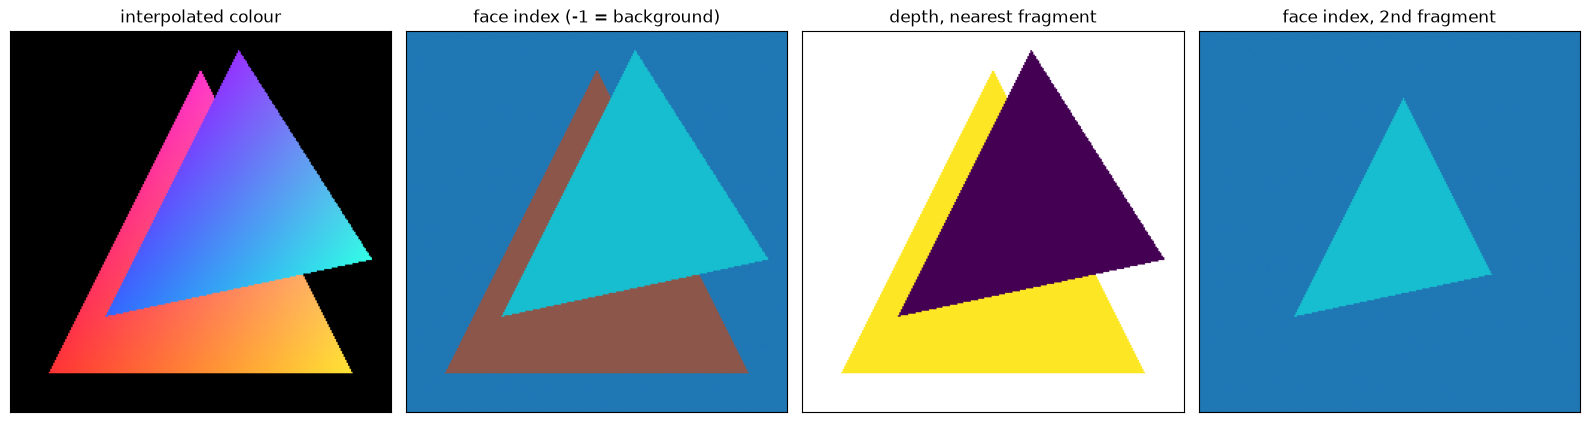

pixels covered by the nearest fragment: 26437 of 65536
pixels where a second fragment exists : 8714


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

ndc, tris = scene("cpu")
face_index, barycentric, depth, signed_distance = g.render.rasterize(
    ndc, tris, image_height=256, image_width=256, faces_per_pixel=2)

# One RGB colour per face corner, so interpolation gives a smooth gradient across each triangle.
colours = torch.tensor([
    [[1.0, 0.2, 0.2], [1.0, 0.9, 0.2], [1.0, 0.2, 0.8]],   # face 0
    [[0.2, 0.4, 1.0], [0.2, 1.0, 0.9], [0.6, 0.2, 1.0]],   # face 1
], dtype=torch.float64)

rgb = g.render.interpolate(face_index, barycentric, colours)

# Barycentric weights sum to 1 only to within rounding, so a channel can land a few ulp above
# 1.0 and matplotlib complains. Clamping for display changes nothing about the computed values.
display = rgb.clamp(0.0, 1.0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
axes[0].imshow(display[0, :, :, 0, :].numpy())
axes[0].set_title("interpolated colour")
axes[1].imshow(face_index[0, :, :, 0].numpy(), cmap="tab10")
axes[1].set_title("face index (-1 = background)")
axes[2].imshow(depth[0, :, :, 0].numpy(), cmap="viridis")
axes[2].set_title("depth, nearest fragment")
axes[3].imshow(face_index[0, :, :, 1].numpy(), cmap="tab10")
axes[3].set_title("face index, 2nd fragment")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print("pixels covered by the nearest fragment:", int((face_index[..., 0] >= 0).sum()),
      "of", 256 * 256)
print("pixels where a second fragment exists :", int((face_index[..., 1] >= 0).sum()))

### The same render on the GPU, pixel for pixel

Rasterisation is where a GPU backend would most plausibly diverge - tie-breaking between fragments
at equal depth is exactly the kind of thing a parallel implementation gets subtly wrong. The kernel
gives one thread per pixel, so each pixel owns its own fragment list and scans faces in ascending
order, which resolves an exact depth tie the same way the CPU does.

In [10]:
if HAVE_CUDA:
    ndc_gpu, tris_gpu = scene("cuda")
    gpu_out = g.render.rasterize(
        ndc_gpu, tris_gpu, image_height=256, image_width=256, faces_per_pixel=2)

    cpu_out = (face_index, barycentric, depth, signed_distance)
    for name, a, b in zip(["face_index", "barycentric", "depth", "signed_distance"],
                          cpu_out, gpu_out):
        print("%-16s identical: %s" % (name, torch.equal(a, b.cpu())))
else:
    print("no CUDA device on this machine; skipping")

face_index       identical: True
barycentric      identical: True
depth            identical: True
signed_distance  identical: True


## 6. Batching without padding

gffx batches by packing elements end to end and marking the boundaries with an `int32` offset
tensor of length `B+1`. Nothing is padded to a common size, so a batch of one large mesh and one
tiny mesh costs what those two meshes cost, rather than twice the larger.

For a single element you can leave the offsets out and they are synthesised for you.

In [11]:
# Two point sets packed into one tensor: three points, then two.
points = torch.tensor([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0],
                       [5.0, 5.0, 5.0], [6.0, 5.0, 5.0]], dtype=torch.float64)
point_offsets = torch.tensor([0, 3, 5], dtype=torch.int32)

# One 4x4 matrix per batch element: the first translates, the second scales.
matrices = torch.stack([
    torch.tensor([[1.0, 0, 0, 10.0], [0, 1.0, 0, 0], [0, 0, 1.0, 0], [0, 0, 0, 1.0]],
                 dtype=torch.float64),
    torch.tensor([[2.0, 0, 0, 0], [0, 2.0, 0, 0], [0, 0, 2.0, 0], [0, 0, 0, 1.0]],
                 dtype=torch.float64),
])

homogeneous = g.transforms.transform_points(points, matrices, point_offsets)
print("packed result [P,4]:\n", homogeneous)
print("\nfirst three rows translated by +10 in x; last two doubled.")

ndc_points, ok = g.transforms.perspective_divide(homogeneous)
print("\nafter the perspective divide:\n", ndc_points)
print("all w finite and non-zero:", bool(ok.all()))

packed result [P,4]:
 tensor([[10.,  0.,  0.,  1.],
        [11.,  0.,  0.,  1.],
        [10.,  1.,  0.,  1.],
        [10., 10., 10.,  1.],
        [12., 10., 10.,  1.]], dtype=torch.float64)

first three rows translated by +10 in x; last two doubled.

after the perspective divide:
 tensor([[10.,  0.,  0.],
        [11.,  0.,  0.],
        [10.,  1.,  0.],
        [10., 10., 10.],
        [12., 10., 10.]], dtype=torch.float64)
all w finite and non-zero: True


## 7. Mesh inspection

`validate` **reports**; it does not gate. An operation kernel rejects the first problem it finds,
because it must not dereference bad memory. This surveys the whole mesh and hands back every defect
at once, which is what you want when you are trying to work out why a mesh someone sent you is
behaving oddly.

Passing it exempts no later call from its own checks.

In [12]:
# A deliberately broken mesh: a degenerate face, and a vertex nothing references.
bad_vertices = torch.tensor(
    [[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [9.0, 9.0, 9.0]],
    dtype=torch.float64)
bad_faces = torch.tensor([[0, 1, 2], [0, 1, 1]], dtype=torch.int32)

report = g.mesh.validate(bad_vertices, bad_faces, check_geometry=True)
print("clean :", report.is_clean)
print("says  :", report.describe())
print()
print("degenerate faces     :", report.degenerate_face_count)
print("unreferenced vertices:", report.unreferenced_vertex_count)
print("non-finite vertices  :", report.nonfinite_vertex_count)

print("\nthe tetrahedron:", g.mesh.validate(vertices, faces, check_geometry=True).describe())

clean : False
says  : degenerate face, unreferenced vertex (1 degenerate; 1 unreferenced)

degenerate faces     : 1
unreferenced vertices: 1
non-finite vertices  : 0

the tetrahedron: clean


## 8. CPU-only operations

These have no CUDA kernel yet. They are not lesser operations - `vertex_normals` is the one most
people reach for first - they are simply the ones that *accumulate*, summing a contribution from
every face incident to a vertex.

That is why they are harder to put on a GPU while keeping the bit-identity promise: floating-point
addition is not associative, so `(a + b) + c` and `a + (b + c)` can differ in the last bit. Getting
the same answer as the CPU means fixing the summation order, which a naive parallel scatter does
not do.

In [13]:
area_weighted = g.mesh.vertex_normals(vertices, faces)
uniform = g.mesh.vertex_normals(vertices, faces, weighting=g.mesh.WEIGHTING_UNIFORM)

print("area-weighted normals:\n", area_weighted)
print("\nall unit length:",
      torch.allclose(area_weighted.norm(dim=1), torch.ones(4, dtype=torch.float64)))
print("the two weightings differ:", not torch.equal(area_weighted, uniform))

edges, edge_face_offsets, edge_faces, mesh_edge_offsets = g.mesh.build_edge_topology(faces)
edge_count = int(mesh_edge_offsets[-1])
print("\nundirected edges:", edge_count, "(a tetrahedron has 6)")
print(edges[:edge_count])

area-weighted normals:
 tensor([[-0.5774, -0.5774, -0.5774],
        [ 1.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000]], dtype=torch.float64)

all unit length: True
the two weightings differ: True

undirected edges: 6 (a tetrahedron has 6)
tensor([[0, 1],
        [0, 2],
        [0, 3],
        [1, 2],
        [1, 3],
        [2, 3]], dtype=torch.int32)


## Where this stands

| | |
|---|---|
| **CPU** | every operation, forward and backward |
| **CUDA** | the eight order-independent operations, forward only, bit-identical to the CPU |
| **Next** | `build_edge_topology` on the GPU, which yields the vertex-incidence structure the accumulating operations need |

This notebook imports the installed `gffx` wheel, the same one the test suite runs against. After
rebuilding the C library, reinstall the wheel into the kernel's environment; nothing is copied by
hand. The status table above is as of 2026-08-28 and lags the CUDA work that followed; the
authoritative state is the project plan.
